# Khai phá Dữ liệu (EDA) - DSLIB Dataset
Notebook này phân tích chuyên sâu bộ dữ liệu **RCPSP** (Resource Constrained Project Scheduling Problem).

Mục tiêu là tìm ra các **Insight quan trọng** về:
1. Phân bố quy mô dự án (Số lượng Task, Edges).
2. Phân bố Thời gian và Chi phí của các Task.
3. Thống kê nguồn lực (Resource Demand).
4. Độ phức tạp của Đồ thị (Graph Density).
5. Mổ xẻ chi tiết Cấu trúc Liên kết của các dự án.

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Nạp toàn bộ dữ liệu dự án
Đọc tất cả các file `nodes.csv` và `edges.csv` từ thư mục `data/processed/`.

In [ ]:
PROCESSED_DIR = '../data/processed'
# Loại bỏ các thư mục rác do Excel tự tạo (Bắt đầu bằng ~$)
project_dirs = [d for d in glob.glob(os.path.join(PROCESSED_DIR, '*')) if not os.path.basename(d).startswith('~$')]
print(f'Total valid projects found: {len(project_dirs)}')

project_stats = []
all_nodes = []

for pdir in project_dirs:
    pname = os.path.basename(pdir)
    nodes_file = os.path.join(pdir, 'nodes.csv')
    edges_file = os.path.join(pdir, 'edges.csv')
    
    if not os.path.exists(nodes_file) or not os.path.exists(edges_file):
        continue
        
    # Bắt lỗi đọc file rỗng (Nếu dự án không có Edge nào)
    try:
        df_n = pd.read_csv(nodes_file)
    except pd.errors.EmptyDataError:
        df_n = pd.DataFrame()
        
    try:
        df_e = pd.read_csv(edges_file)
    except pd.errors.EmptyDataError:
        df_e = pd.DataFrame(columns=['source', 'target', 'type'])
    
    num_nodes = len(df_n)
    num_edges = len(df_e)
    
    if num_nodes == 0:
        continue
        
    total_cost = df_n['total_cost'].sum() if 'total_cost' in df_n.columns else 0
    
    # Tính độ phức tạp đồ thị (Density)
    density = num_edges / (num_nodes * (num_nodes - 1) / 2) if num_nodes > 1 else 0
    
    project_stats.append({
        'Project': pname,
        'Num Tasks': num_nodes,
        'Num Edges': num_edges,
        'Total Cost': total_cost,
        'Graph Density': density
    })
    all_nodes.append(df_n)

df_stats = pd.DataFrame(project_stats)
df_all_nodes = pd.concat(all_nodes, ignore_index=True)
df_stats.head()

Total valid projects found: 231


,Project,Num Tasks,Num Edges,Total Cost,Graph Density
0,C2011-01 Nursing Home Noordhinder,186,152,1.336363e+07,0.008835
1,C2011-02 Social Housing Kortrijk,132,111,2.233472e+06,0.012838
2,C2011-03 Family Day,23,21,6.335000e+04,0.083004
3,C2011-04 Railway Station Sint-Joost,19,17,1.196615e+05,0.099415
4,C2011-05 Telecom System Agnes,22,20,3.609705e+05,0.086580


## 2. Phân bố Quy mô Dự án
Tìm hiểu xem phần lớn các dự án trong DSLIB có bao nhiêu Task. Điều này giúp thiết lập kích thước Input (Graph Size) cho AI.

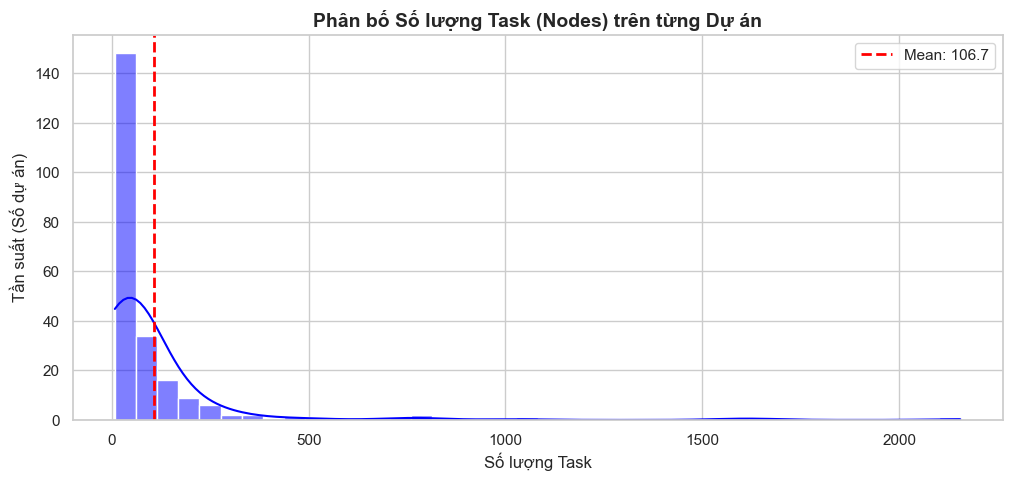

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(df_stats['Num Tasks'], bins=40, kde=True, color='blue')
plt.title('Phân bố Số lượng Task (Nodes) trên từng Dự án', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Task', fontsize=12)
plt.ylabel('Tần suất (Số dự án)', fontsize=12)
plt.axvline(df_stats['Num Tasks'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df_stats["Num Tasks"].mean():.1f}')
plt.legend()
plt.show()

## 3. Phân bố Thời gian thực hiện (Duration) của các Task

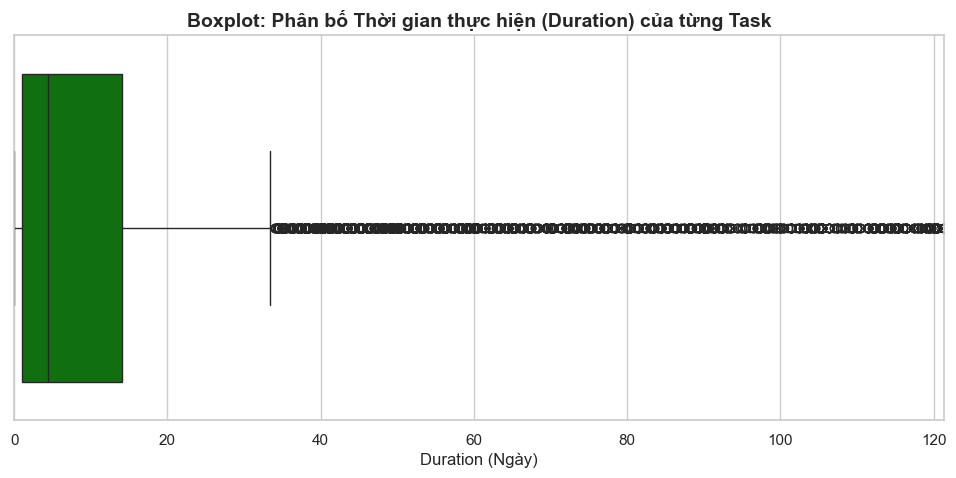

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df_all_nodes['duration'], color='green')
plt.title('Boxplot: Phân bố Thời gian thực hiện (Duration) của từng Task', fontsize=14, fontweight='bold')
plt.xlabel('Duration (Ngày)', fontsize=12)
plt.xlim(0, df_all_nodes['duration'].quantile(0.95)) # Cắt bỏ Outliers 5% trên cùng để dễ nhìn
plt.show()

## 4. Độ phức tạp của Đồ thị (Graph Density)
Đo lường mức độ chằng chịt của các ràng buộc (Dependencies).

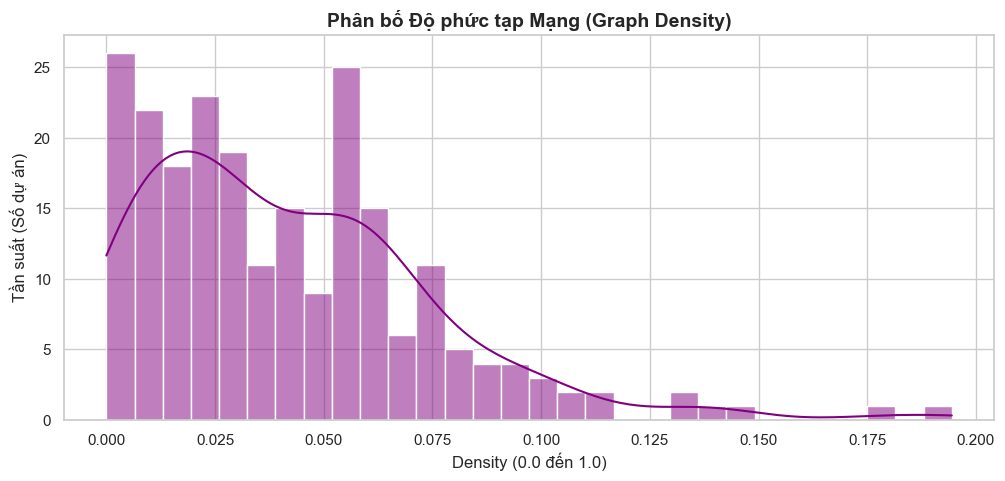

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(df_stats['Graph Density'], bins=30, kde=True, color='purple')
plt.title('Phân bố Độ phức tạp Mạng (Graph Density)', fontsize=14, fontweight='bold')
plt.xlabel('Density (0.0 đến 1.0)', fontsize=12)
plt.ylabel('Tần suất (Số dự án)', fontsize=12)
plt.show()

## 5. Khai phá Dữ liệu Tài nguyên (Resource Demand)
Top 20 tài nguyên/nhân sự được gọi tên nhiều nhất trong toàn bộ lịch sử 232 dự án.

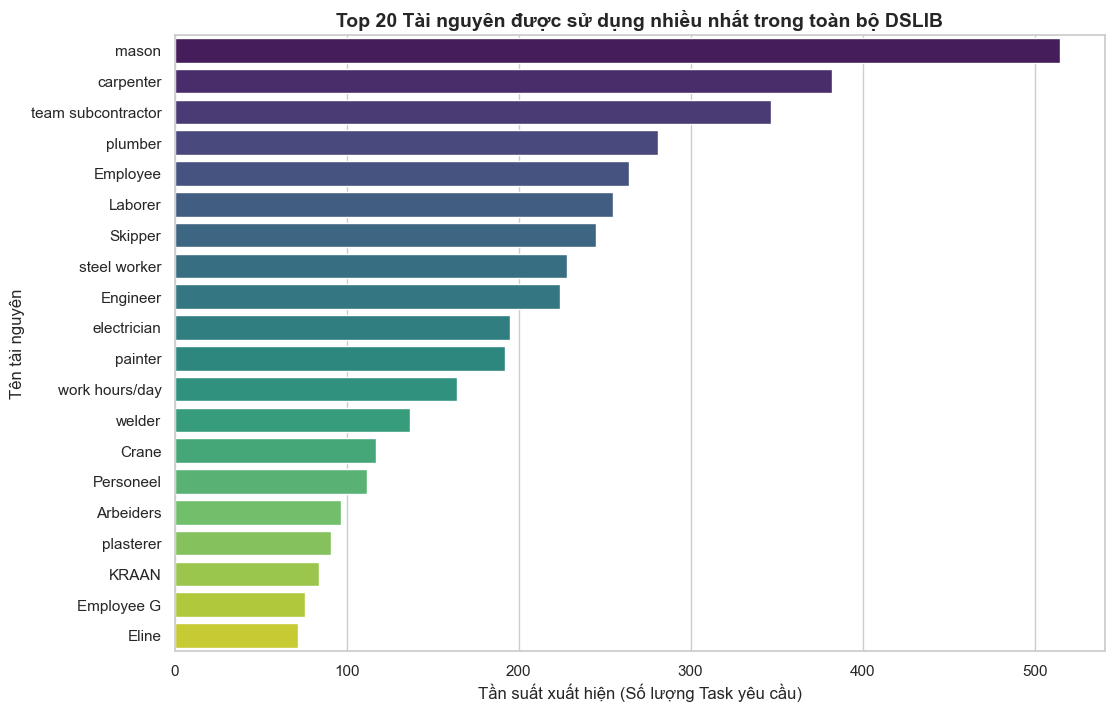

In [ ]:
import re
from collections import Counter

# Lấy tất cả chuỗi tài nguyên không bị NaN
resources_list = df_all_nodes['resource_demand'].dropna().tolist()

all_resource_names = []
for res_str in resources_list:
    items = res_str.split(';')
    for item in items:
        # Lấy phần chữ trước dấu [
        name = item.split('[')[0].strip()
        if name:
            all_resource_names.append(name)

res_counter = Counter(all_resource_names)
top_res = pd.DataFrame(res_counter.most_common(20), columns=['Resource Name', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Resource Name', data=top_res, palette='viridis')
plt.title('Top 20 Tài nguyên được sử dụng nhiều nhất trong toàn bộ DSLIB', fontsize=14, fontweight='bold')
plt.xlabel('Tần suất xuất hiện (Số lượng Task yêu cầu)', fontsize=12)
plt.ylabel('Tên tài nguyên', fontsize=12)
plt.show()

---
## 6. Phân tích Chuyên sâu (Deep Dive): 3 Dự án gần đây nhất
Lấy ra 3 dự án mới nhất (dựa theo tên thư mục) để vẽ Sơ đồ mạng lưới (Network Graph) và Phân bổ Chi phí.

In [ ]:
# Lấy 3 dự án cuối cùng (C2025...)
recent_projects = sorted(project_dirs)[-3:]
print("3 dự án mới nhất để phân tích chuyên sâu:")
for p in recent_projects:
    print(" -", os.path.basename(p))


3 dự án mới nhất để phân tích chuyên sâu:
 - C2025-26 MEJORAMIENTO DEL PARQUE
 - C2025-27  CREACION DEL PAVIMENTADO
 - C2025-28 CRONOGRAMA DE OBRA


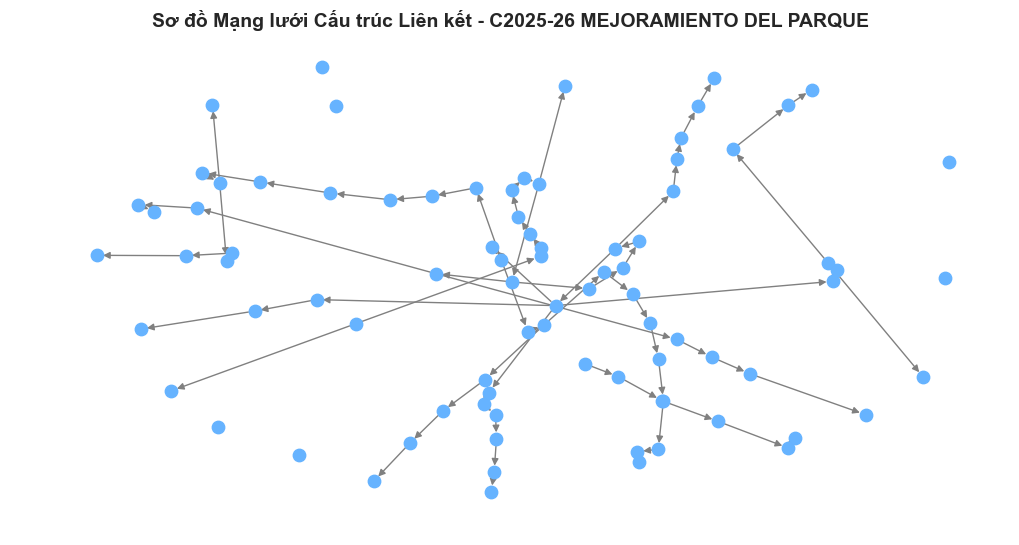

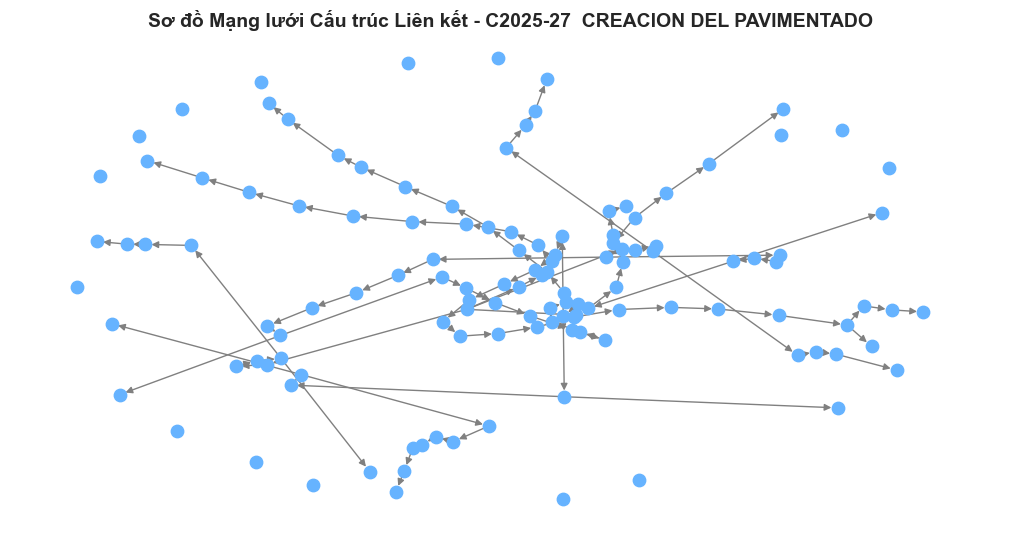

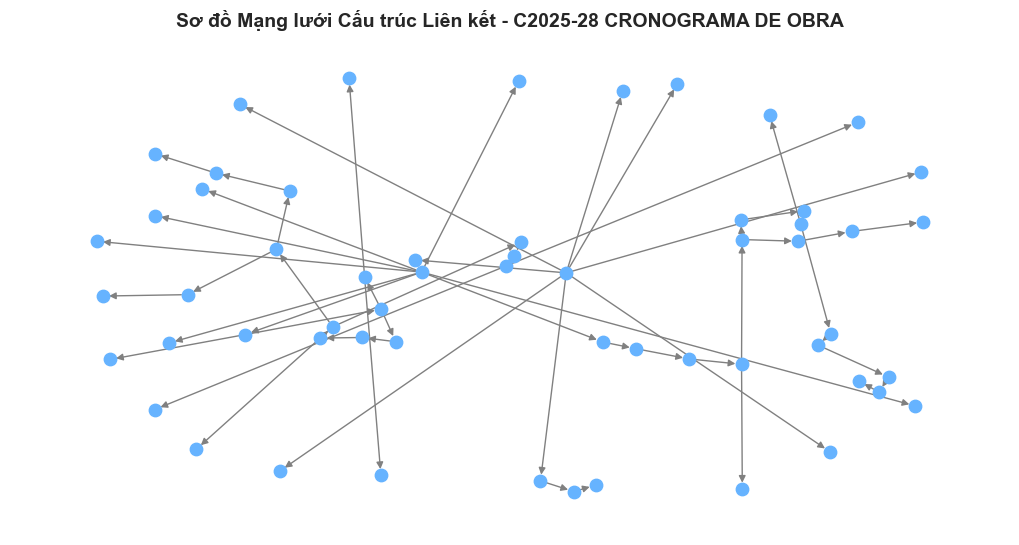

In [ ]:
for pdir in recent_projects:
    pname = os.path.basename(pdir)
    nodes_file = os.path.join(pdir, 'nodes.csv')
    if not os.path.exists(nodes_file):
        continue
    df_n = pd.read_csv(nodes_file)
    
    try:
        df_e = pd.read_csv(os.path.join(pdir, 'edges.csv'))
    except pd.errors.EmptyDataError:
        df_e = pd.DataFrame(columns=['source', 'target', 'type'])
    
    # 1. Vẽ Network Graph (Cấu trúc mạng)
    G = nx.DiGraph()
    for _, row in df_n.iterrows():
        G.add_node(str(row['node_id']))
    for _, row in df_e.iterrows():
        G.add_edge(str(row['source']), str(row['target']))
    
    plt.figure(figsize=(10, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=False, node_color='#66b3ff', edge_color='gray', node_size=80, arrows=True)
    plt.title(f'Sơ đồ Mạng lưới Cấu trúc Liên kết - {pname}', fontweight='bold', fontsize=14)
    plt.show()
    
    # 2. Phân bố Chi phí (Top 10 Task)
    if 'total_cost' in df_n.columns and df_n['total_cost'].sum() > 0:
        top_cost_tasks = df_n.nlargest(10, 'total_cost')
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_cost_tasks, x='total_cost', y='task_name', palette='Reds_r')
        plt.title(f'Top 10 Task Tốn kém nhất - {pname}', fontweight='bold', fontsize=14)
        plt.xlabel('Chi phí')
        plt.ylabel('Tên Task')
        plt.show()
